#### Задача 1 Анализ успеваемости студентов
В университете есть список студентов и их оценок по разным курсам. Данные представлены в виде списка кортежей:

In [3]:
students_data = [
    ('Анна', 'Математика', 4),
    ('Борис', 'Физика', 5),
    ('Анна', 'Физика', 3),
    ('Сергей', 'Математика', 5),
    ('Борис', 'Математика', 4),
    ('Сергей', 'Физика', 4)
]

Напишите функцию analyze_grades(data), которая:

1. Для каждого студента выводит средний балл по всем курсам.
2. Находит курс с наивысшей средней оценкой (если несколько курсов имеют одинаковый средний балл — выбрать первый по порядку появления в данных).
3. Возвращает словарь с двумя ключами:
    * *'students_avg'* — словарь {имя: средний_балл};
    * *'best_course'* — название курса с максимальной средней оценкой.

Требования к функции:

* Обрабатывает данные за один проход (без многократного перебора списка).
* Округляет средние баллы до 1 знака после запятой.
* Если студент записан на один курс — средний балл равен его оценке.

In [ ]:
def analyze_grades(data):
    # Словари для накопления данных
    student_grades = {}  # {имя: [оценки]}
    course_grades = {}   # {курс: [оценки]}

    
    # Проходим по всем записям один раз
    for name, course, grade in data:
        # Накопление оценок студента
        if name not in student_grades:
            student_grades[name] = []
        student_grades[name].append(grade)
        
        # Накопление оценок курса
        if course not in course_grades:
            course_grades[course] = []
        course_grades[course].append(grade)
    
    # Считаем средние баллы студентов
    students_avg = {}
    for name, grades in student_grades.items():
        avg = round(sum(grades) / len(grades), 1)
        students_avg[name] = avg
    
    # Ищем курс с максимальной средней оценкой
    best_course = None
    best_avg = 0
    for course, grades in course_grades.items():
        avg = sum(grades) / len(grades)
        if avg > best_avg:
            best_avg = avg
            best_course = course
    
    return {
        'students_avg': students_avg,
        'best_course': best_course
    }

In [4]:
# Пример использования
result = analyze_grades(students_data)
print(result)

{'students_avg': {'Анна': 3.5, 'Борис': 4.5, 'Сергей': 4.5}, 'best_course': 'Математика'}


#### Задача 2. Оптимизация автобусных маршрутов

В городе работают 4 автобусных маршрута. Для каждого известны:

* номер маршрута (int);

* длина трассы (км);

* средний пассажиропоток в день (человек).

Нужно написать функции, чтобы:

* посчитать загруженность маршрута (пассаж./км);

* выделить маршруты, где загруженность ниже 200 пас./км (требуют пересмотра);

* найти маршрут с максимальной загруженностью.

In [ ]:
routes = [
    {"number": 12, "length": 18.4, "passengers": 3200},
    {"number": 25, "length": 24.1, "passengers": 6100},
    {"number": 7,  "length": 15.8, "passengers": 2100},
    {"number": 44, "length": 30.2, "passengers": 4800}
]

Задание

1. Напишите функцию *load_per_km(route)*, которая вычисляет загруженность (пас./км, округлённо до 1 знака после запятой).

2. С помощью *map()* получите список загруженностей для всех маршрутов.

3. Напишите функцию *needs_review(load*), возвращающую *True*, если загруженность < 200.

4. С помощью *filter()* найдите маршруты, требующие пересмотра, и выведите их номера.

5. С помощью *max()* и ключа *key* найдите маршрут с максимальной загруженностью и выведите его номер и значение.

In [ ]:
# Функция для расчёта загруженности
def load_per_km(route):
    return round(route["passengers"] / route["length"], 1)

# Получаем список загруженностей через map()
loads = list(map(load_per_km, routes))

# Функция для проверки необходимости пересмотра
def needs_review(load):
    return load < 200

# Находим маршруты на пересмотр
routes_to_review = list(filter(lambda r: needs_review(load_per_km(r)), routes))
review_numbers = []
for r in routes_to_review:
    review_numbers.append(r["number"]) 

# Находим маршрут с максимальной загруженностью
most_loaded = max(routes, key=load_per_km)
most_loaded_number = most_loaded["number"]
most_loaded_value = load_per_km(most_loaded)


# Вывод результата
print(f"Загруженность (пас./км): {loads}")
print(f"Маршруты на пересмотр: {review_numbers}")
print(f"Самый загруженный маршрут: №{most_loaded_number} ({most_loaded_value} пас./км)")

#### Задача 3. Анализ загруженности городских парков

Городская служба мониторинга собирает данные о посещаемости парков. Вам нужно написать функцию, которая на основе этих данных рассчитает ключевые показатели и выдаст рекомендации.

Входные данные
Словарь *park_data* с информацией о парках:

In [ ]:
park_data = {
    "Центральный": {"visitors_day": 1200, "area_ha": 50, "entrances": 4},
    "Лесной": {"visitors_day": 350, "area_ha": 120, "entrances": 2},
    "Детский": {"visitors_day": 800, "area_ha": 25, "entrances": 3},
    "Заречный": {"visitors_day": 600, "area_ha": 80, "entrances": 2}
}

Напишите функцию *analyze_parks(data, threshold=50)*:

* Параметр *data* — входной словарь с данными о парках.

* Параметр *threshold* — пороговая плотность посетителей (чел./га), по которой парк считается перегруженным (по умолчанию 50).

Функция должна:

1. Для каждого парка рассчитать:
* плотность посетителей (чел./га) = *visitors_day / area_ha*;
* нагрузку на вход (чел./вход) = *visitors_day / entrances*.

2. Сформировать новый словарь, где для каждого парка будут:
* "density" — плотность посетителей (округление до 1 знака);
* "entrance_load" — нагрузка на вход (округление до целого);
* "status" — строка "перегружен" или "в норме" (сравнивать плотность с *threshold*).

3. Вернуть сформированный словарь.

**Ожидаемый результат**

При вызове *analyze_parks(park_data, threshold=50)* функция должна вернуть:

In [ ]:
{
    'Центральный': {'density': 24.0, 'entrance_load': 300, 'status': 'в норме'},
    'Лесной': {'density': 2.9, 'entrance_load': 175, 'status': 'в норме'},
    'Детский': {'density': 32.0, 'entrance_load': 267, 'status': 'в норме'},
    'Заречный': {'density': 7.5, 'entrance_load': 300, 'status': 'в норме'}
}

In [ ]:
def analyze_parks(park_data, threshold=50):
    key_list = []
    value_list =[]
    for name, info in park_data.items():
        density = info['visitors_day'] / info['area_ha']
        entrance_load = info['visitors_day'] / info['entrances']
        stat = lambda den: 'перегружен' if den > threshold else 'в норме' # тут можно без лямбды: status = 'перегружен' if density > threshold else 'в норме'
        status = stat(density) 
        key_list.append(name)
        value_list.append({'density': round(density, 1), 'entrance_load': round(entrance_load), 'status': status})
    return dict(zip(key_list, value_list))

In [3]:
analyze_parks(park_data, threshold=50)

{'Центральный': {'density': 24.0, 'entrance_load': 300, 'status': 'в норме'},
 'Лесной': {'density': 2.9, 'entrance_load': 175, 'status': 'в норме'},
 'Детский': {'density': 32.0, 'entrance_load': 267, 'status': 'в норме'},
 'Заречный': {'density': 7.5, 'entrance_load': 300, 'status': 'в норме'}}

#### Задача 4. Анализ использования городских электросамокатов
Городская служба проката электросамокатов собирает данные о поездках. Информация поступает в упрощённом JSON‑подобном формате — список словарей:

In [12]:
rides = [
    {"user_id": 101, "duration_min": 15, "distance_km": 2.3, "start_zone": "Центр"},
    {"user_id": 102, "duration_min": 8, "distance_km": 1.1, "start_zone": "Спальный"},
    {"user_id": 103, "duration_min": 22, "distance_km": 3.5, "start_zone": "Парк"},
    {"user_id": 101, "duration_min": 12, "distance_km": 1.8, "start_zone": "Центр"},
    {"user_id": 104, "duration_min": 30, "distance_km": 4.2, "start_zone": "Спальный"}
]


**Требуется**

Написать функцию *analyze_scooter_usage(data)*, которая:

1. Для каждой поездки вычисляет скорость (км/ч) по формуле:
    *скорость = (distance_km / duration_min) * 60.*
2. Добавляет в каждую запись поле *"speed_kmh"* с рассчитанной скоростью (округление до 1 знака).
3. Возвращает новый список словарей с полями:
    *{"user_id", "duration_min", "distance_km", "start_zone", "speed_kmh"}*

**Ограничения и требования**

* Использовать map() и lambda для обработки каждой поездки.
* Не изменять исходные данные.
* Скорость рассчитывать только для поездок длительностью > 0 мин.
* Если duration_min == 0, устанавливать speed_kmh = 0.0.

In [ ]:
def analyze_scooter_usage(data):
    calculate_speed = lambda ride: (
        0.0 if ride["duration_min"] == 0
        else round((ride["distance_km"] / ride["duration_min"]) * 60, 1)
    )
    for ride in data:
         ride['speed_kmh'] = calculate_speed(ride)

    return data

In [27]:
# Запуск и вывод результата
result = analyze_scooter_usage(rides)
for item in result:
    print(item)

{'user_id': 101, 'duration_min': 15, 'distance_km': 2.3, 'start_zone': 'Центр', 'speed_kmh': 9.2}
{'user_id': 102, 'duration_min': 8, 'distance_km': 1.1, 'start_zone': 'Спальный', 'speed_kmh': 8.2}
{'user_id': 103, 'duration_min': 22, 'distance_km': 3.5, 'start_zone': 'Парк', 'speed_kmh': 9.5}
{'user_id': 101, 'duration_min': 12, 'distance_km': 1.8, 'start_zone': 'Центр', 'speed_kmh': 9.0}
{'user_id': 104, 'duration_min': 30, 'distance_km': 4.2, 'start_zone': 'Спальный', 'speed_kmh': 8.4}


#### Задача 5. Работа с файлами

Напишем скрипт, который создаёт файл, копирует его и удаляет оригинал.

In [ ]:
import os
import shutil

# Создаём файл original.txt и записываем в него строку
file_path = 'original.txt'
with open(file_path, 'w') as f:
    f.write("Это оригинальный файл.\n")


# Проверяем, существует ли файл
if os.path.exists(file_path):
    print("Файл успешно создан:", file_path)


# Копируем файл
shutil.copy(file_path, 'copy.txt')
print("Файл скопирован как copy.txt")


# Переименовываем копию
os.rename('copy.txt', 'renamed_copy.txt')
print("Файл переименован в renamed_copy.txt")


# Удаляем оригинальный файл
os.remove(file_path)
print("Оригинальный файл удалён")


# Проверяем, существует ли переименованная копия файла
if os.path.exists('renamed_copy.txt'):
    print("Копия файла существует!")

#### Задача 6. Анализ загруженности городских парковок
Городская администрация ведёт учёт свободных мест на общественных парковках. Данные хранятся в текстовом файле *parkings.txt* в формате. 

Каждая строка — одна парковка. Поля разделены точкой с запятой.

**Требуется**

Написать скрипт, который:

* Прочитает данные из файла *parkings.txt*.
* Для каждой парковки вычислит процент занятости (занято / вместимость × 100, округление до 1 знака).
* Добавит в каждую запись поле *занятость_%*.
* Отфильтрует парковки, где *занятость > 80 %*.
* Сохранит результат в новый файл *high_load_parkings.txt* в том же формате, но только для отфильтрованных парковок.

**Формат выходного файла**

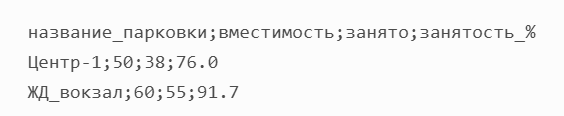

In [ ]:
# Шаг 1. Чтение данных из файла
with open('../../data/parkings.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Шаг 2. Обработка данных
result_lines = []

for i, line in enumerate(lines):
    if i == 0:  # Пропускаем первую строку (заголовок)
        continue
    if line.strip():  # пропускаем пустые строки
        name, capacity, occupied = line.strip().split(';')
        capacity = int(capacity)
        occupied = int(occupied)
        
        # Вычисляем процент занятости
        load_percent = round(occupied / capacity * 100, 1)
        
        # Формируем новую строку с полем занятости
        new_line = f"{name};{capacity};{occupied};{load_percent}\n"
        
        # Добавляем в результат, если занятость > 80%
        if load_percent > 80:
            result_lines.append(new_line)

# Шаг 3. Запись в новый файл
with open('../../data/high_load_parkings.txt', 'w', encoding='utf-8') as f:
    f.write("название_парковки;вместимость;занято;занятость_%\n")  # заголовок
    f.writelines(result_lines)